In [31]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict
from dotenv import load_dotenv

In [32]:
load_dotenv()
model=ChatGoogleGenerativeAI(model="models/gemini-3-flash-preview")

In [33]:
class BlogState(TypedDict):
    title:str
    outline:str
    contant:str

In [34]:
def creat_outline(state:BlogState)->BlogState:
    title=state['title']

    prompt=f"genreate a outline on the given title{title}"
    outline=model.invoke(prompt).content


    return {"outline":outline}

In [43]:
def creat_blog(state:BlogState)->BlogState:
    title=state['title']
    outline=state['outline']

    prompt=f"genreate a detailed blog on the given title/n{title}/n using the following outline /n {outline}"
    contant=model.invoke(prompt).content


    return {"contant":contant}

In [44]:
graph=StateGraph(BlogState)

graph.add_node('creat_outline',creat_outline)
graph.add_node('creat_blog',creat_blog)

graph.add_edge(START,'creat_outline')
graph.add_edge('creat_outline','creat_blog')
graph.add_edge('creat_blog',END)

workflow=graph.compile()

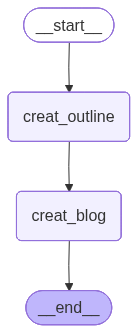

In [45]:
workflow

In [46]:
initial_state={'title':'Rise of AI in India'}
final_state=workflow.invoke(initial_state)
print(final_state)

{'title': 'Rise of AI in India', 'outline': [{'type': 'text', 'text': 'This comprehensive outline explores the **Rise of AI in India**, covering the drivers of growth, key sectors, government initiatives, challenges, and the future outlook.\n\n---\n\n### **Title: The Rise of AI in India: From Back-Office to Global Powerhouse**\n\n#### **I. Introduction**\n*   **Definition of AI in the Indian Context:** Briefly defining Artificial Intelligence and its significance in the "Digital India" era.\n*   **The "AI for All" Vision:** Mentioning India’s unique approach to using AI for social inclusion.\n*   **Thesis Statement:** India is transitioning from a global IT service provider to an AI-driven innovation hub, fueled by massive data, a young workforce, and proactive government policy.\n\n#### **II. The Pillars of Growth (Why Now?)**\n*   **Massive Data Availability:** The "Jio Effect" and the lowest data costs in the world providing the fuel for machine learning.\n*   **Human Capital:** Ind